Loaded summaries and eval arrays.


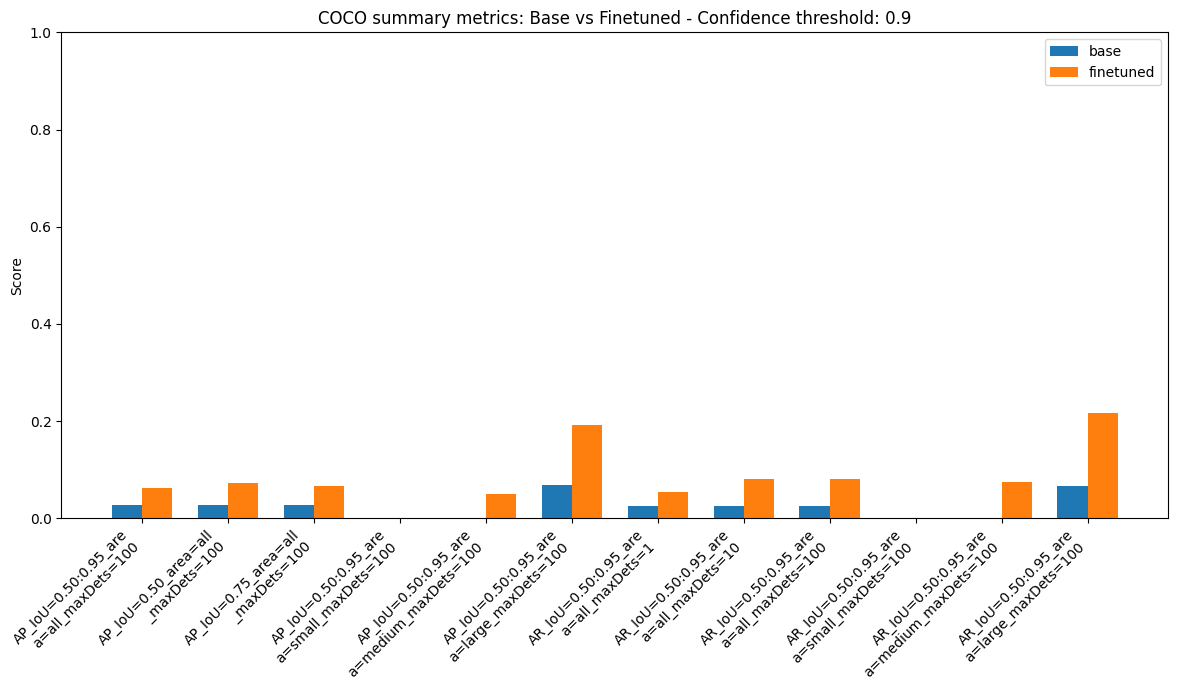

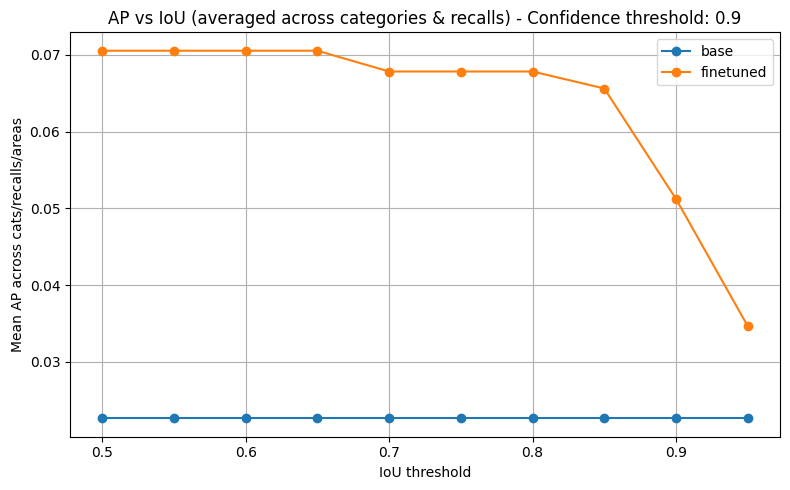

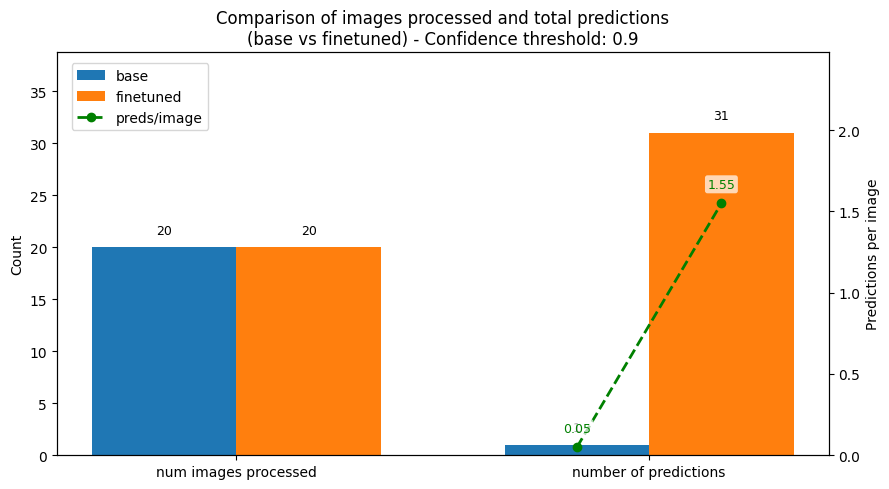

Saved cleaned comparison plot to: plots\conf-0.9\images_and_predictions_comparison-Confidence threshold-0.9.png


In [ ]:
# Visualize comparison between two COCO evaluation results
# Save this file as a Jupyter-friendly Python script or paste into a notebook cell.
# Expected folders (change at top):
#  - evaluation_visualize/base_result/
#      - coco_summary_with_meta.json
#      - coco_eval_details.npz
#  - evaluation_visualize/finetuned_best_result/
#      - coco_summary_with_meta.json
#      - coco_eval_details.npz
# The script produces many plots (PNG) under evaluation_visualize/plots/

# %%
import json
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import math
import textwrap

# %%
# -------- CONFIG (edit paths / params here) --------
TARGET_CONF_THRES = 0.55

BASE_DIR = Path(f"./base_result/conf-{TARGET_CONF_THRES}")
FINETUNE_DIR = Path(f"./finetuned_best_result/conf-{TARGET_CONF_THRES}")
PLOT_DIR = Path(f"./plots/conf-{TARGET_CONF_THRES}")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

BASE_SUMMARY_JSON = BASE_DIR / "coco_summary_with_meta.json"
BASE_EVAL_NPZ = BASE_DIR / "coco_eval_details.npz"

FT_SUMMARY_JSON = FINETUNE_DIR / "coco_summary_with_meta.json"
FT_EVAL_NPZ = FINETUNE_DIR / "coco_eval_details.npz"

# top-k categories to show when plotting per-category AP
TOPK_CATS = 30
AREA_IDX = 0       # which area range index to use when extracting per-cat AP (default 'all')
MAX_DET_IDX = -1   # last index often corresponds to maxDets=100
IOU_IDX_FOR_PR = 0 # which IoU index to use for plotting PR curves

# ---------------------------------------------------

# %%
# Utility loaders

def load_summary(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Summary JSON not found: {path}")
    with open(path, "r") as f:
        return json.load(f)


def load_eval_npz(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Eval NPZ not found: {path}")
    data = np.load(path, allow_pickle=True)
    out = {
        "precision": data.get("precision", None),
        "recall": data.get("recall", None),
        "scores": data.get("scores", None),
        "metadata_json": None,
    }
    if "metadata_json" in data:
        try:
            out["metadata_json"] = json.loads(data["metadata_json"].item())
        except Exception:
            try:
                out["metadata_json"] = json.loads(str(data["metadata_json"]))
            except Exception:
                out["metadata_json"] = None
    return out

# %%
# Loading both results
base_summary = load_summary(BASE_SUMMARY_JSON)
ft_summary = load_summary(FT_SUMMARY_JSON)

base_eval = load_eval_npz(BASE_EVAL_NPZ)
ft_eval = load_eval_npz(FT_EVAL_NPZ)

# convenience: flatten summary -> dict of name->value
base_stats = base_summary.get("summary", {})
ft_stats = ft_summary.get("summary", {})

base_meta = base_summary.get("metadata", {})
ft_meta = ft_summary.get("metadata", {})

print("Loaded summaries and eval arrays.")

# %%
# Helper: compute AP per IoU (overall average across categories, recalls, areas, maxDets)
def ap_per_iou_from_precision(precision):
    # precision shape: [T, R, K, A, M]
    if precision is None or precision.size == 0:
        return None
    T = precision.shape[0]
    ap_by_iou = []
    for t in range(T):
        arr = precision[t, :, :, :, :]
        valid = arr[arr > -1]
        if valid.size == 0:
            ap_by_iou.append(float("nan"))
        else:
            ap_by_iou.append(float(np.mean(valid)))
    return ap_by_iou

# Helper: compute per-category AP (averaged across IoUs & recalls)
def per_category_ap_from_precision(precision, area_idx=AREA_IDX, max_det_idx=MAX_DET_IDX):
    # precision: [T, R, K, A, M]
    if precision is None or precision.size == 0:
        return []
    T, R, K, A, M = precision.shape
    # For each category index k compute mean of valid precision entries across T and R for chosen area/maxdet
    ap_per_cat = []
    for k in range(K):
        sub = precision[:, :, k, area_idx, max_det_idx]
        vals = sub[sub > -1]
        if vals.size == 0:
            ap = float('nan')
        else:
            ap = float(np.mean(vals))
        ap_per_cat.append((k, ap))
    return ap_per_cat

# Helper: extract PR curve for a category and IoU index
def pr_curve_for_cat(precision, recall_array, cat_idx, iou_idx=IOU_IDX_FOR_PR, area_idx=AREA_IDX, max_det_idx=MAX_DET_IDX):
    # precision [T,R,K,A,M]; recall may be an array or recThrs was not saved
    if precision is None or precision.size == 0:
        return None, None
    T, R, K, A, M = precision.shape
    if iou_idx < 0 or iou_idx >= T:
        raise IndexError("iou_idx out of range")
    prec = precision[iou_idx, :, cat_idx, area_idx, max_det_idx]  # shape [R]
    # replace -1 with nan for plotting continuity
    prec_plot = np.array([np.nan if p <= -1 else p for p in prec])
    # recall array: if saved recall array exists in COCOeval.eval it usually has shape [T, K, A, M]
    # but not always. We'll try to build x-axis as linspace if not available.
    if recall_array is None or recall_array.size == 0:
        recall_x = np.linspace(0.0, 1.0, len(prec_plot))
    else:
        # recall_array might be [T, K, A, M] or [R] depending on how it was saved
        arr = recall_array
        if arr.ndim == 1 and arr.shape[0] == prec_plot.shape[0]:
            recall_x = arr
        else:
            # fallback
            recall_x = np.linspace(0.0, 1.0, len(prec_plot))
    return recall_x, prec_plot

# %%
# 1) Plot the 12 COCO summary metrics comparison (side-by-side bar chart)
stat_names = list(base_stats.keys()) if base_stats else []
if not stat_names:
    # default labels if summaries were saved differently
    stat_names = [
        "AP_IoU=0.50:0.95_area=all_maxDets=100",
        "AP_IoU=0.50_area=all_maxDets=100",
        "AP_IoU=0.75_area=all_maxDets=100",
        "AP_IoU=0.50:0.95_area=small_maxDets=100",
        "AP_IoU=0.50:0.95_area=medium_maxDets=100",
        "AP_IoU=0.50:0.95_area=large_maxDets=100",
        "AR_IoU=0.50:0.95_area=all_maxDets=1",
        "AR_IoU=0.50:0.95_area=all_maxDets=10",
        "AR_IoU=0.50:0.95_area=all_maxDets=100",
        "AR_IoU=0.50:0.95_area=small_maxDets=100",
        "AR_IoU=0.50:0.95_area=medium_maxDets=100",
        "AR_IoU=0.50:0.95_area=large_maxDets=100",
    ]
conf_thrs = base_meta.get('conf_threshold') or (base_eval.get('metadata_json') or {}).get('conf_threshold')

base_values = [base_stats.get(n, None) for n in stat_names]
ft_values = [ft_stats.get(n, None) for n in stat_names]

# convert None/NaN to np.nan for plotting
base_vals_plot = [np.nan if v is None else float(v) for v in base_values]
ft_vals_plot = [np.nan if v is None else float(v) for v in ft_values]

x = np.arange(len(stat_names))
width = 0.35

plt.figure(figsize=(12, 7))
plt.bar(x - width/2, base_vals_plot, width)
plt.bar(x + width/2, ft_vals_plot, width)
plt.xticks(x, [textwrap.fill(s, 20) for s in stat_names], rotation=45, ha='right')
plt.ylabel('Score')
plt.title(f'COCO summary metrics: Base vs Finetuned - Confidence threshold: {conf_thrs}')
plt.legend(['base', 'finetuned'])
plt.ylim(0, 1.0)
plt.tight_layout()
plt.savefig(PLOT_DIR / f'summary_bar_base_vs_finetuned-Confidence threshold-{conf_thrs}.png')
plt.show()

# %%
# 2) AP vs IoU line plot
base_precision = base_eval.get('precision')
ft_precision = ft_eval.get('precision')

base_ap_iou = ap_per_iou_from_precision(base_precision)
ft_ap_iou = ap_per_iou_from_precision(ft_precision)

# x-axis: IoU thresholds from metadata if available
base_iou_thrs = base_meta.get('iou_thrs') or (base_eval.get('metadata_json') or {}).get('iou_thrs')
ft_iou_thrs = ft_meta.get('iou_thrs') or (ft_eval.get('metadata_json') or {}).get('iou_thrs')

iou_x = None
if base_iou_thrs is not None:
    iou_x = base_iou_thrs
elif ft_iou_thrs is not None:
    iou_x = ft_iou_thrs
else:
    # fallback to indices
    if base_ap_iou is not None:
        iou_x = list(range(len(base_ap_iou)))
    elif ft_ap_iou is not None:
        iou_x = list(range(len(ft_ap_iou)))

if base_ap_iou is not None or ft_ap_iou is not None:
    plt.figure(figsize=(8,5))
    if base_ap_iou is not None:
        plt.plot(iou_x, base_ap_iou, marker='o', label='base')
    if ft_ap_iou is not None:
        plt.plot(iou_x, ft_ap_iou, marker='o', label='finetuned')
    plt.xlabel('IoU threshold')
    plt.ylabel('Mean AP across cats/recalls/areas')
    plt.title(f'AP vs IoU (averaged across categories & recalls) - Confidence threshold: {conf_thrs}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'ap_vs_iou_base_vs_finetuned-Confidence threshold-{conf_thrs}.png')
    plt.show()


#3 "num_images_processed", "number_of_predictions" plot
keys = ["num_images_processed", "number_of_predictions"]

# Helper to read numeric metadata safely
def safe_get(meta, k):
    try:
        v = meta.get(k, None)
        if v is None:
            return np.nan
        return float(v)
    except Exception:
        return np.nan

# get values (expects base_meta and ft_meta dicts to be present)
base_vals = np.array([safe_get(base_meta, k) for k in keys], dtype=float)
ft_vals   = np.array([safe_get(ft_meta,   k) for k in keys], dtype=float)

# Basic layout
x = np.arange(len(keys))           # [0, 1]
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))

# Primary bars: base and finetuned
bars1 = ax.bar(x - width/2, base_vals, width, label='base', zorder=2)
bars2 = ax.bar(x + width/2, ft_vals, width, label='finetuned', zorder=2)

# set primary y-limit with margin so bar labels don't touch the top border
max_count = np.nanmax([np.nanmax(base_vals), np.nanmax(ft_vals), 1.0])
ax.set_ylim(0, max_count * 1.25)

# Annotate integer counts above each bar (with margin)
def annotate_bars(bars, fmt='{:.0f}'):
    margin = max(1.0, 0.02 * max_count)
    for b in bars:
        h = b.get_height()
        if np.isnan(h):
            txt = 'n/a'
            ax.text(b.get_x() + b.get_width()/2, margin, txt, ha='center', va='bottom', fontsize=9)
        else:
            ax.text(b.get_x() + b.get_width()/2, h + margin, fmt.format(h),
                    ha='center', va='bottom', fontsize=9, clip_on=False)

annotate_bars(bars1)
annotate_bars(bars2)

ax.set_xticks(x)
ax.set_xticklabels([k.replace('_',' ') for k in keys])
ax.set_ylabel('Count')
ax.set_title(f'Comparison of images processed and total predictions\n(base vs finetuned) - Confidence threshold: {conf_thrs}')

# Secondary axis for preds-per-image
ax2 = ax.twinx()
ax2.set_ylabel('Predictions per image')

# compute ratios
def ratio(preds, imgs):
    try:
        if np.isnan(preds) or np.isnan(imgs) or imgs == 0:
            return np.nan
        return preds / imgs
    except Exception:
        return np.nan

base_ratio = ratio(base_vals[1], base_vals[0])
ft_ratio   = ratio(ft_vals[1], ft_vals[0])

# plot the preds-per-image line *above the prediction bars only*
# pick the x coordinates that correspond to the prediction bars centers:
pred_x_base = x[1] - width/2   # base bar for 'number_of_predictions'
pred_x_ft   = x[1] + width/2   # finetuned bar for 'number_of_predictions'

# set y-limits for secondary axis with margin so markers/labels don't clip
max_ratio = np.nanmax([base_ratio, ft_ratio, 1.0])
if np.isnan(max_ratio) or max_ratio == 0:
    max_ratio = 1.0
ax2.set_ylim(0, max_ratio * 1.6)

# draw the line between the two prediction bars (so it doesn't sweep across the entire chart)
ax2.plot([pred_x_base, pred_x_ft],
         [base_ratio, ft_ratio],
         marker='o', linestyle='--', linewidth=2, label='preds/image',
         color="green", zorder=5)

# annotate the preds/image markers, offset so text doesn't overlap the marker or border
for xi, val in [(pred_x_base, base_ratio), (pred_x_ft, ft_ratio)]:
    if not np.isnan(val):
        ax2.annotate(f'{val:.2f}',
                     xy=(xi, val),
                     xytext=(0, 9),                # 9 points above the marker
                     textcoords='offset points',
                     ha='center', va='bottom',
                     fontsize=9, color='green', zorder=6,
                     bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

# Put legends separately to avoid overlap
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper left', bbox_to_anchor=(0.01, 0.99))

plt.tight_layout()
out_path = PLOT_DIR / f'images_and_predictions_comparison-Confidence threshold-{conf_thrs}.png'
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()

print(f"Saved cleaned comparison plot to: {out_path}")